In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [3]:
df_r = pd.read_csv("aita_raw_large.csv")

In [4]:
df_r['is_asshole'].unique()

array([1, 0])

In [5]:
print(df_r['is_asshole'].value_counts())

is_asshole
0    71117
1    26511
Name: count, dtype: int64


In [6]:
df = pd.read_csv("aita_raw_large.csv")

In [28]:
df.head()

,title,body,verdict,score,num_comments,is_asshole,text
0,[AITA] I wrote an explanation in TIL and came ...,[Here is the post in question](http://www.redd...,asshole,52,13.0,1,Here is the post in question It seems like I c...
1,[AITA] Threw my parent's donuts away,"My parents are diabetic, morbidly obese, and a...",asshole,140,27.0,1,"My parents are diabetic, morbidly obese, and a..."
2,I told a goth girl she looked like a clown.,I was four.,not the asshole,74,15.0,0,I was four.
3,[AItA]: Argument I had with another redditor i...,http://www.reddit.com/r/HIMYM/comments/1vvfkq/...,everyone sucks,22,3.0,1,
4,[AITA] I let my story get a little long and bo...,NaN,not the asshole,6,4.0,0,


In [8]:
df = df.drop(columns=['id', 'timestamp', 'edited'])

In [9]:
print(df['is_asshole'].value_counts())

is_asshole
0    71117
1    26511
Name: count, dtype: int64


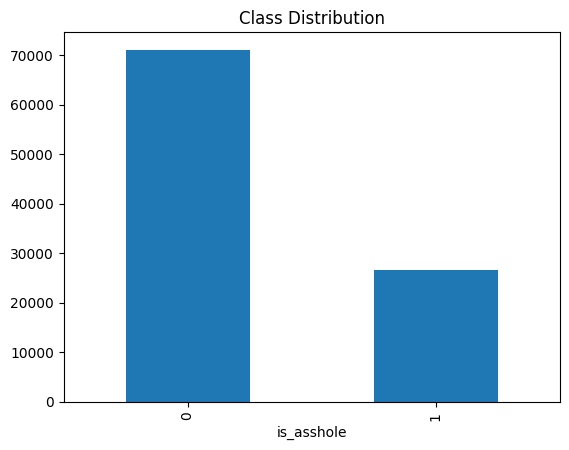

In [10]:
df['is_asshole'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

In [11]:
df['body'] = df['body'].str.replace(r"\'", "", regex=True)

In [13]:
df['text'] = df['title'].astype(str) + " " + df['body'].astype(str)

In [15]:
df['text'] = df['title'].astype(str) + " " + df['body'].astype(str)
df['text'] = df['text'].str.replace(r"\n", " ", regex=True)
df['text'] = df['body'].str.replace(r'"', '', regex=True)

In [22]:
df['text']

0        Here is the post in question It seems like I c...
1        My parents are diabetic, morbidly obese, and a...
2                                              I was four.
3                                                         
4                                                         
                               ...                        
97623    My sisterF and IM are white kids born and rais...
97624    My husband M and I F are married for a little ...
97625    Upfront apologies for formatting. I’m also try...
97626    A little back story my mom is a drug addict an...
97627    I’m a F apprentice in the trades. I work on in...
Name: text, Length: 97628, dtype: object

In [17]:
df['text'] = df['text'].fillna('').astype(str)

In [18]:
def clean_text(text):
    # Step A: Remove URLs (http://... or https://... or www...)
    # We do this FIRST so we don't accidentally break the URL by removing numbers inside it
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[\[\]\(\)\d]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [21]:
df['text'] = df['text'].apply(clean_text)

In [29]:
df = df.drop(columns=['title', 'body'])

In [30]:
col_to_move = df.pop('text')
df.insert(0, 'text', col_to_move)

In [31]:
df_nta = df[df['is_asshole'] == 0]
df_yta = df[df['is_asshole'] == 1]

In [32]:
df_nta_balanced = df_nta.sample(n=len(df_yta), random_state=42)

In [33]:
df_balanced = pd.concat([df_nta_balanced, df_yta])

In [34]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [87]:
df_balanced.to_csv("aita_balanced.csv", index=False)

In [35]:
df.to_csv('aita_cleaned.csv', index=False)